# 第6章: 単語ベクトル

単語の意味を実ベクトルで表現する単語ベクトル（単語埋め込み）に関して、以下の処理を行うプログラムを作成せよ。

## 50. 単語ベクトルの読み込みと表示

Google Newsデータセット（約1,000億単語）での[学習済み単語ベクトル](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit?usp=sharing)（300万単語・フレーズ、300次元）をダウンロードし、"United States"の単語ベクトルを表示せよ。ただし、"United States"は内部的には"United_States"と表現されていることに注意せよ。

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.9 MB/s eta 0:00:00


In [2]:
from gensim.models import KeyedVectors

In [3]:
# モデルの読み込み
model_path = 'GoogleNews-vectors-negative300.bin.gz'
word_vectors = KeyedVectors.load_word2vec_format(model_path, binary=True)

In [ ]:
# "United_States" のベクトルを取得
vector = word_vectors['United_States']

print(vector)

[-3.61328125e-02 -4.83398438e-02  2.35351562e-01  1.74804688e-01
 -1.46484375e-01 -7.42187500e-02 -1.01562500e-01 -7.71484375e-02
  1.09375000e-01 -5.71289062e-02 -1.48437500e-01 -6.00585938e-02
  1.74804688e-01 -7.71484375e-02  2.58789062e-02 -7.66601562e-02
 -3.80859375e-02  1.35742188e-01  3.75976562e-02 -4.19921875e-02
 -3.56445312e-02  5.34667969e-02  3.68118286e-04 -1.66992188e-01
 -1.17187500e-01  1.41601562e-01 -1.69921875e-01 -6.49414062e-02
 -1.66992188e-01  1.00585938e-01  1.15722656e-01 -2.18750000e-01
 -9.86328125e-02 -2.56347656e-02  1.23046875e-01 -3.54003906e-02
 -1.58203125e-01 -1.60156250e-01  2.94189453e-02  8.15429688e-02
  6.88476562e-02  1.87500000e-01  6.49414062e-02  1.15234375e-01
 -2.27050781e-02  3.32031250e-01 -3.27148438e-02  1.77734375e-01
 -2.08007812e-01  4.54101562e-02 -1.23901367e-02  1.19628906e-01
  7.44628906e-03 -9.03320312e-03  1.14257812e-01  1.69921875e-01
 -2.38281250e-01 -2.79541016e-02 -1.21093750e-01  2.47802734e-02
  7.71484375e-02 -2.81982

## 51. 単語の類似度

"United States"と"U.S."のコサイン類似度を計算せよ。

In [ ]:
# コサイン類似度の計算
similarity_score = word_vectors.similarity("United_States", "U.S.")

print(f"コサイン類似度：{similarity_score:.4f}")

コサイン類似度：0.7311


## 52. 類似度の高い単語10件

"United States"とコサイン類似度が高い10語と、その類似度を出力せよ。

In [5]:
# 類似度が高いトップ10を取得
# most_similarは (単語, 類似度) のタプルのリストを返す
similar_words = word_vectors.most_similar("United_States", topn=10)

print(f"{'順位':<4} | {'単語':<20} | {'コサイン類似度'}")
print("-" * 50)

for i, data in enumerate(similar_words):
    word = data[0]
    similarity = data[1]

    print(f"{i+1:<4} | {word:<20} | {similarity:.6f}")

順位   | 単語                   | コサイン類似度
--------------------------------------------------
1    | Unites_States        | 0.787725
2    | Untied_States        | 0.754137
3    | United_Sates         | 0.740072
4    | U.S.                 | 0.731077
5    | theUnited_States     | 0.640439
6    | America              | 0.617841
7    | UnitedStates         | 0.616731
8    | Europe               | 0.613299
9    | countries            | 0.604480
10   | Canada               | 0.601907


## 53. 加法構成性によるアナロジー

"Spain"の単語ベクトルから"Madrid"のベクトルを引き、"Athens"のベクトルを足したベクトルを計算し、そのベクトルと類似度の高い10語とその類似度を出力せよ。

In [6]:
# 足す単語（ベクトルを加算）
positive_words = ['Spain', 'Athens']
# 引く単語（ベクトルを減算）
negative_words = ['Madrid']

# "Spain" - "Madrid" + "Athens" の計算と、類似語トップ10の取得
similar_words = word_vectors.most_similar(positive=positive_words, negative=negative_words, topn=10)

print(f"{'順位':<4} | {'単語':<20} | {'コサイン類似度'}")
print("-" * 50)

for i, data in enumerate(similar_words):
    word = data[0]
    similarity = data[1]
    print(f"{i+1:>4} | {word:<20} | {similarity:.6f}")

順位   | 単語                   | コサイン類似度
--------------------------------------------------
   1 | Greece               | 0.689848
   2 | Aristeidis_Grigoriadis | 0.560685
   3 | Ioannis_Drymonakos   | 0.555291
   4 | Greeks               | 0.545069
   5 | Ioannis_Christou     | 0.540086
   6 | Hrysopiyi_Devetzi    | 0.524844
   7 | Heraklio             | 0.520776
   8 | Athens_Greece        | 0.516881
   9 | Lithuania            | 0.516687
  10 | Iraklion             | 0.514679


## 54. アナロジーデータでの実験

[単語アナロジーの評価データ](http://download.tensorflow.org/data/questions-words.txt)をダウンロードし、国と首都に関する事例（`: capital-common-countries`セクション）に対して、vec(2列目の単語) - vec(1列目の単語) + vec(3列目の単語)を計算し、そのベクトルと類似度が最も高い単語と、その類似度を求めよ。求めた単語と類似度は、各事例と一緒に記録せよ。

In [7]:
# --- 3. 評価データの処理 ---
eval_file = "questions-words.txt"
target_section = ": capital-common-countries"
is_target = False

print(f"{'入力単語(1, 2, 3)':<30} | {'期待される語':<12} | {'予測語':<12} | {'類似度'}")
print("-" * 75)

with open(eval_file, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        # セクションの見出しは : で始まる
        if line.startswith(':'):
            if line == target_section:
                is_target = True
            else:
                is_target = False
            continue

        # ターゲットセクション内の処理
        if is_target:
            words = line.split()
            # 1列目:w1, 2列目:w2, 3列目:w3, 4列目:w4(正解)
            w1, w2, w3, w4_correct = words

            # ユーザー指定の演算: vec(w2) - vec(w1) + vec(w3)
            # gensimのmost_similarでは positive=[w2, w3], negative=[w1] で表現可能
            predicted = word_vectors.most_similar(
                positive=[w2, w3], negative=[w1], topn=1
            )[0]

            pred_word, similarity = predicted

            # 結果の出力
            input_str = f"{w1}, {w2}, {w3}"
            print(f"{input_str:<30} | {w4_correct:<12} | {pred_word:<12} | {similarity:.4f}")

入力単語(1, 2, 3)                  | 期待される語       | 予測語          | 類似度
---------------------------------------------------------------------------
Athens, Greece, Baghdad        | Iraq         | Iraqi        | 0.6352
Athens, Greece, Bangkok        | Thailand     | Thailand     | 0.7138
Athens, Greece, Beijing        | China        | China        | 0.7236
Athens, Greece, Berlin         | Germany      | Germany      | 0.6735
Athens, Greece, Bern           | Switzerland  | Switzerland  | 0.4920
Athens, Greece, Cairo          | Egypt        | Egypt        | 0.7528
Athens, Greece, Canberra       | Australia    | Australia    | 0.5837
Athens, Greece, Hanoi          | Vietnam      | Viet_Nam     | 0.6276
Athens, Greece, Havana         | Cuba         | Cuba         | 0.6461
Athens, Greece, Helsinki       | Finland      | Finland      | 0.6900
Athens, Greece, Islamabad      | Pakistan     | Pakistan     | 0.7233
Athens, Greece, Kabul          | Afghanistan  | Afghan       | 0.6161
Athens, Greece, L

## 55. アナロジータスクでの正解率

54の実行結果を用い、意味的アナロジー（semantic analogy）と文法的アナロジー（syntactic analogy）の正解率を測定せよ。

In [9]:
# コサイン類似度の計算と正誤判定が行われます
# overall_accuracy: 全セクション、全問題を通した総合的な正解率
# detail: 「セクション名（国名、動詞の過去形など）」「正解したリスト」「不正解だったリスト」、辞書のリスト
overall_accuracy, details = word_vectors.evaluate_word_analogies(eval_file)

# 4. 集計用の変数
semantic_correct = 0
semantic_total = 0
syntactic_correct = 0
syntactic_total = 0

# 5. セクションごとに分類して集計
for section in details:
    sec_name = section['section']

    # 正解数と不正解数を取得
    correct_count = len(section['correct'])
    incorrect_count = len(section['incorrect'])
    total_count = correct_count + incorrect_count

    # 評価データ内の単語がモデルの辞書になく、評価対象外となったセクションはスキップ
    if total_count == 0:
        continue

    # セクション名が 'gram' から始まるものは文法的（Syntactic）、それ以外は意味的（Semantic）
    if sec_name.startswith('gram'):
        syntactic_correct += correct_count
        syntactic_total += total_count
    else:
        semantic_correct += correct_count
        semantic_total += total_count

# 6. 正解率の計算関数
def calc_accuracy(correct, total):
    if (total > 0):
        return correct / total * 100
    else:
        return 0.0

semantic_acc = calc_accuracy(semantic_correct, semantic_total)
syntactic_acc = calc_accuracy(syntactic_correct, syntactic_total)
total_acc = calc_accuracy(semantic_correct + syntactic_correct, semantic_total + syntactic_total)

# 7. 結果の出力
print("\n=== アナロジータスク評価結果 ===")
print(f"意味的アナロジー (Semantic)  : {semantic_acc:.2f}% ({semantic_correct} / {semantic_total})")
print(f"文法的アナロジー (Syntactic) : {syntactic_acc:.2f}% ({syntactic_correct} / {syntactic_total})")
print("-" * 50)
print(f"総合正解率 (Total)           : {total_acc:.2f}%")


=== アナロジータスク評価結果 ===
意味的アナロジー (Semantic)  : 74.06% (20725 / 27985)
文法的アナロジー (Syntactic) : 73.90% (7889 / 10675)
--------------------------------------------------
総合正解率 (Total)           : 74.01%


## 56. WordSimilarity-353での評価

[The WordSimilarity-353 Test Collection](http://www.gabrilovich.com/resources/data/wordsim353/wordsim353.html)の評価データをダウンロードし、単語ベクトルにより計算される類似度のランキングと、人間の類似度判定のランキングの間のスピアマン相関係数を計算せよ。

In [8]:
!pip install scipy requests gensim

In [10]:
import os
import requests
from scipy.stats import spearmanr
from gensim.models import KeyedVectors

# --- 1. 評価データのダウンロード ---
def download_ws353():
    # Gensimリポジトリが提供しているクリーンなWS-353データを利用
    url = "https://raw.githubusercontent.com/RaRe-Technologies/gensim/master/gensim/test/test_data/wordsim353.tsv"
    file_name = "wordsim353.tsv"

    if not os.path.exists(file_name):
        print(f"評価データ {file_name} をダウンロード中...")
        response = requests.get(url)
        with open(file_name, 'wb') as f:
            f.write(response.content)
    return file_name


# --- 3. データの読み込みと類似度計算 ---
eval_file = download_ws353()

human_scores = []
vector_scores = []
oov_count = 0  # 辞書にない単語のペア数

with open(eval_file, 'r', encoding='utf-8') as f:
    for line in f:
        # 空行やヘッダー行をスキップ
        if not line.strip() or line.lower().startswith('word'):
            continue

        parts = line.strip().split('\t')

        if len(parts) == 3:
            # w1, w2: 比較対象の単語
            w1, w2, human_score_str = parts

            # 片方でも知らない単語があると計算ができないため、
            # 2つの単語が両方ともモデルの辞書に存在する場合のみ評価
            if (w1 in word_vectors) and (w2 in word_vectors):
                # Word2Vecによるコサイン類似度
                vec_score = word_vectors.similarity(w1, w2)

                # 人間の評価スコア
                human_score = float(human_score_str)

                vector_scores.append(vec_score)
                human_scores.append(human_score)

            else:
                oov_count += 1

# --- 4. スピアマンの順位相関係数の計算 ---
# 2つの配列を渡し、相関係数とp値を取得
correlation, p = spearmanr(human_scores, vector_scores)

# --- 5. 結果の出力 ---
print("\n=== WordSimilarity-353 評価結果 ===")
print(f"評価に使用したペア数 : {len(human_scores)} ペア")
print(f"辞書に無かったペア数 : {oov_count} ペア")
print("-" * 35)
print(f"スピアマン相関係数   : {correlation:.4f}")

評価データ wordsim353.tsv をダウンロード中...

=== WordSimilarity-353 評価結果 ===
評価に使用したペア数 : 352 ペア
辞書に無かったペア数 : 1 ペア
-----------------------------------
スピアマン相関係数   : 0.6996


## 57. k-meansクラスタリング

国名に関する単語ベクトルを抽出し、k-meansクラスタリングをクラスタ数k=5として実行せよ。

In [11]:
!pip install scikit-learn numpy

In [ ]:
import numpy as np
from gensim.models import KeyedVectors
from sklearn.cluster import KMeans

# --- 2. 国名リストの定義 ---
# Geminiが国名をリストアップ
countries = [
    'Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria',
    'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Belize', 'Benin',
    'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Bulgaria', 'Burundi', 'Cambodia', 'Cameroon',
    'Canada', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Costa_Rica', 'Croatia', 'Cuba',
    'Cyprus', 'Denmark', 'Djibouti', 'Dominica', 'Ecuador', 'Egypt', 'Eritrea', 'Estonia',
    'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana',
    'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guyana', 'Haiti', 'Honduras', 'Hungary',
    'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica',
    'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon',
    'Lesotho', 'Liberia', 'Libya', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia',
    'Maldives', 'Mali', 'Malta', 'Mauritania', 'Mauritius', 'Mexico', 'Micronesia', 'Moldova',
    'Monaco', 'Mongolia', 'Montenegro', 'Morocco', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal',
    'Netherlands', 'Nicaragua', 'Niger', 'Nigeria', 'Norway', 'Oman', 'Pakistan', 'Palau',
    'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Romania',
    'Russia', 'Rwanda', 'Samoa', 'Senegal', 'Serbia', 'Seychelles', 'Singapore', 'Slovakia',
    'Slovenia', 'Somalia', 'Spain', 'Sudan', 'Suriname', 'Sweden', 'Switzerland', 'Syria',
    'Taiwan', 'Tajikistan', 'Tanzania', 'Thailand', 'Togo', 'Tonga', 'Tunisia', 'Turkey',
    'Turkmenistan', 'Uganda', 'Ukraine', 'Uruguay', 'Uzbekistan', 'Vanuatu', 'Venezuela',
    'Vietnam', 'Yemen', 'Zambia', 'Zimbabwe', 'United_States', 'United_Kingdom', 'South_Korea',
    'North_Korea', 'South_Africa', 'New_Zealand', 'Saudi_Arabia', 'Sri_Lanka'
]

# --- 3. 単語ベクトルの抽出 ---
valid_countries = []
country_vectors = []

for country in countries:
    if country in word_vectors:
        # 「計算に使えることが確認できた国名」のリストについか
        valid_countries.append(country)
        # その国名に対応する「ベクトルデータ（数値の配列）」のリスト
        country_vectors.append(word_vectors[country])
    else:
        print(f"警告: '{country}' は辞書に存在しません。")

# scikit-learnで扱えるようにNumPy配列に変換
X = np.array(country_vectors)

# --- 4. k-meansクラスタリングの実行 ---
num_clusters = 5
print(f"\n{len(valid_countries)}か国のベクトルを {num_clusters} つのクラスタに分類中...")

# random_stateを固定して結果の再現性を確保
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans.fit(X)

# --- 5. 結果の集計と出力 ---
# 各クラスタに所属する国をリストにまとめる
# 5個の空のリストを作成
clusters = {i: [] for i in range(num_clusters)}

# valid_countries: 元の国名のリスト
# kmeans.labels_: 各データに割り振られたグループ番号
for country, label in zip(valid_countries, kmeans.labels_):
    clusters[label].append(country)

print("\n=== クラスタリング結果 ===")
for i in range(num_clusters):
    print(f"\n■ クラスタ {i+1} ({len(clusters[i])}か国):")

    # 見やすいようにカンマ区切りで出力し、長すぎる場合は折り返す
    cluster_countries = ", ".join(clusters[i])
    import textwrap
    print(textwrap.fill(cluster_countries, width=80, subsequent_indent="  "))


159か国のベクトルを 5 つのクラスタに分類中...

=== クラスタリング結果 ===

■ クラスタ 1 (14か国):
Armenia, Azerbaijan, Belarus, Georgia, Iran, Kazakhstan, Kyrgyzstan, Moldova,
  Mongolia, Russia, Tajikistan, Turkmenistan, Ukraine, Uzbekistan

■ クラスタ 2 (27か国):
Argentina, Bahamas, Belize, Bolivia, Brazil, Canada, Chile, Colombia,
  Costa_Rica, Cuba, Dominica, Ecuador, Grenada, Guatemala, Guyana, Haiti,
  Honduras, Jamaica, Mexico, Nicaragua, Panama, Paraguay, Peru, Samoa, Suriname,
  Uruguay, Venezuela

■ クラスタ 3 (43か国):
Algeria, Angola, Benin, Botswana, Burundi, Cameroon, Chad, Comoros, Djibouti,
  Egypt, Eritrea, Ethiopia, Gabon, Gambia, Ghana, Guinea, Kenya, Lesotho,
  Liberia, Libya, Madagascar, Malawi, Mali, Mauritania, Mauritius, Morocco,
  Mozambique, Namibia, Niger, Nigeria, Rwanda, Senegal, Seychelles, Somalia,
  Sudan, Tanzania, Togo, Tunisia, Uganda, Yemen, Zambia, Zimbabwe, South_Africa

■ クラスタ 4 (41か国):
Afghanistan, Australia, Bahrain, Bangladesh, Bhutan, Cambodia, China, Fiji,
  India, Indonesia, Iraq, Isr

## 58. Ward法によるクラスタリング

国名に関する単語ベクトルに対し、Ward法による階層型クラスタリングを実行せよ。さらに、クラスタリング結果をデンドログラムとして可視化せよ。

モデルを読み込んでいます...
Ward法による階層型クラスタリングを実行中...
デンドログラムを描画します...


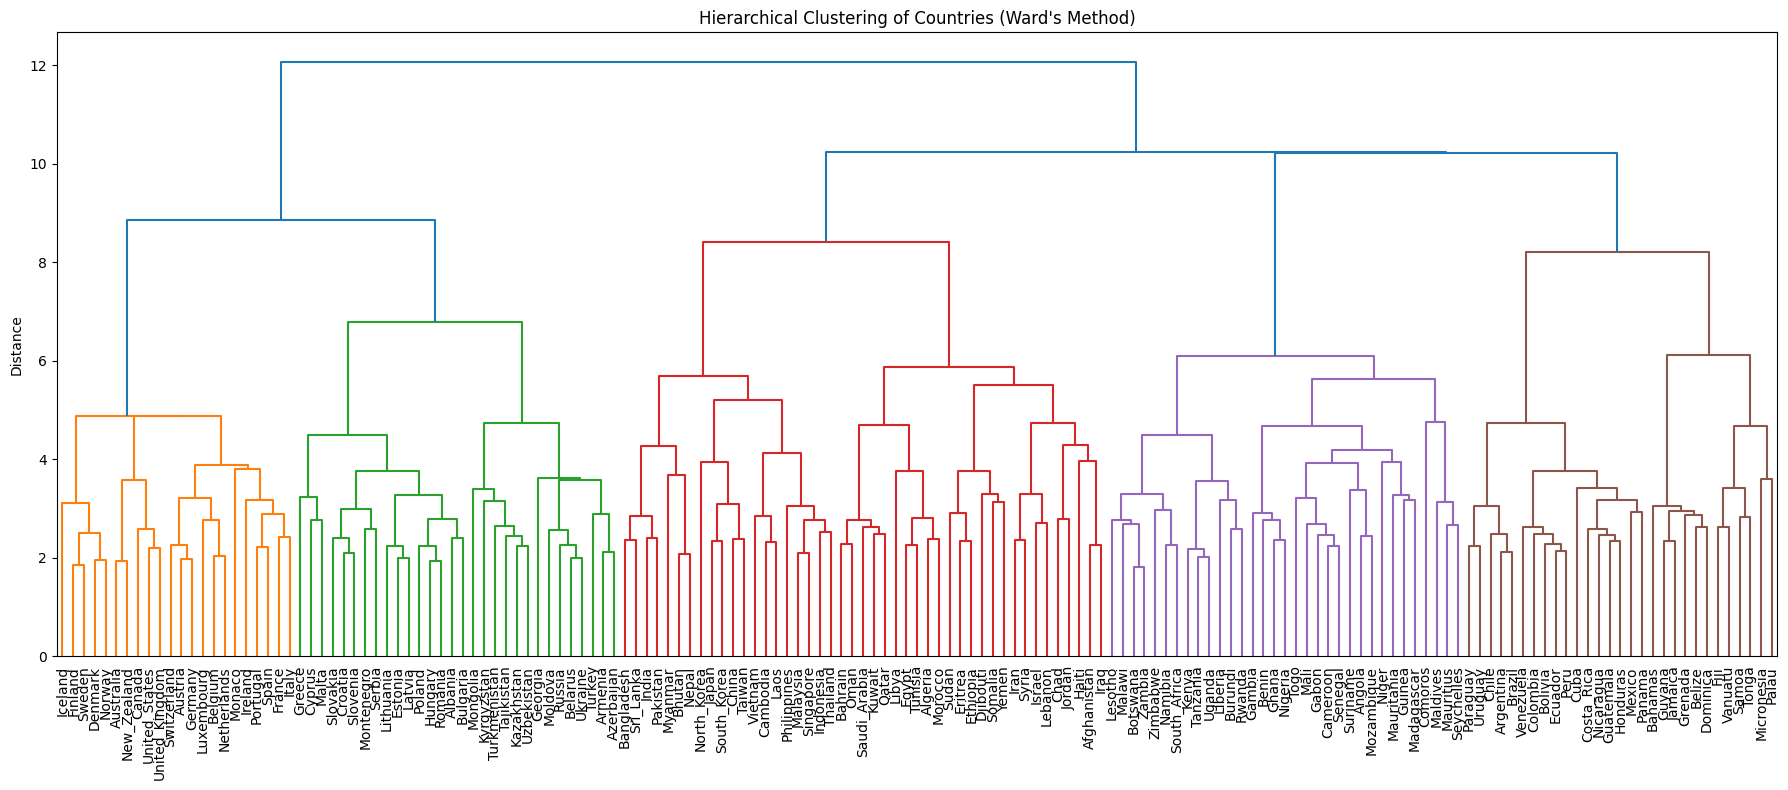

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from gensim.models import KeyedVectors

# --- 2. 国名リストの定義 ---
# （前回のk-meansと同じリストを使用します）
countries = [
    'Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria',
    'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Belize', 'Benin',
    'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Bulgaria', 'Burundi', 'Cambodia', 'Cameroon',
    'Canada', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Costa_Rica', 'Croatia', 'Cuba',
    'Cyprus', 'Denmark', 'Djibouti', 'Dominica', 'Ecuador', 'Egypt', 'Eritrea', 'Estonia',
    'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana',
    'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guyana', 'Haiti', 'Honduras', 'Hungary',
    'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica',
    'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon',
    'Lesotho', 'Liberia', 'Libya', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia',
    'Maldives', 'Mali', 'Malta', 'Mauritania', 'Mauritius', 'Mexico', 'Micronesia', 'Moldova',
    'Monaco', 'Mongolia', 'Montenegro', 'Morocco', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal',
    'Netherlands', 'Nicaragua', 'Niger', 'Nigeria', 'Norway', 'Oman', 'Pakistan', 'Palau',
    'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Romania',
    'Russia', 'Rwanda', 'Samoa', 'Senegal', 'Serbia', 'Seychelles', 'Singapore', 'Slovakia',
    'Slovenia', 'Somalia', 'Spain', 'Sudan', 'Suriname', 'Sweden', 'Switzerland', 'Syria',
    'Taiwan', 'Tajikistan', 'Tanzania', 'Thailand', 'Togo', 'Tonga', 'Tunisia', 'Turkey',
    'Turkmenistan', 'Uganda', 'Ukraine', 'Uruguay', 'Uzbekistan', 'Vanuatu', 'Venezuela',
    'Vietnam', 'Yemen', 'Zambia', 'Zimbabwe', 'United_States', 'United_Kingdom', 'South_Korea',
    'North_Korea', 'South_Africa', 'New_Zealand', 'Saudi_Arabia', 'Sri_Lanka'
]

# --- 3. 単語ベクトルの抽出 ---
valid_countries = []
country_vectors = []

for country in countries:
    if country in word_vectors:
        valid_countries.append(country)
        country_vectors.append(word_vectors[country])

# numpy配列に変換
X = np.array(country_vectors)

# --- 4. 階層型クラスタリング（Ward法）の実行 ---
print("Ward法による階層型クラスタリングを実行中...")
# linkage関数で距離計算とクラスタの結合を行います
# method='ward' を指定することでWard法を使用します
Z = linkage(X, method='ward')

# --- 5. デンドログラムの描画 ---
print("デンドログラムを描画します...")
plt.figure(figsize=(18, 8)) # 横長にして見やすくする

# デンドログラムの作成
dendrogram(
    Z,
    labels=valid_countries,  # x軸のラベルに国名を設定
    leaf_rotation=90,        # ラベルを90度回転させて重なりを防ぐ
    leaf_font_size=10,       # フォントサイズ
    color_threshold=0.7 * max(Z[:,2]) # クラスタの色分けの閾値（全体距離の70%を目安）
)

plt.title("Hierarchical Clustering of Countries (Ward's Method)")
plt.ylabel("Distance")

# レイアウトを整えて表示
plt.tight_layout()
plt.show()

## 59. t-SNEによる可視化

ベクトル空間上の国名に関する単語ベクトルをt-SNEで可視化せよ。

In [ ]:
from sklearn.manifold import TSNE

t-SNEによる次元削減を実行中... (数秒かかります)
グラフを描画します...


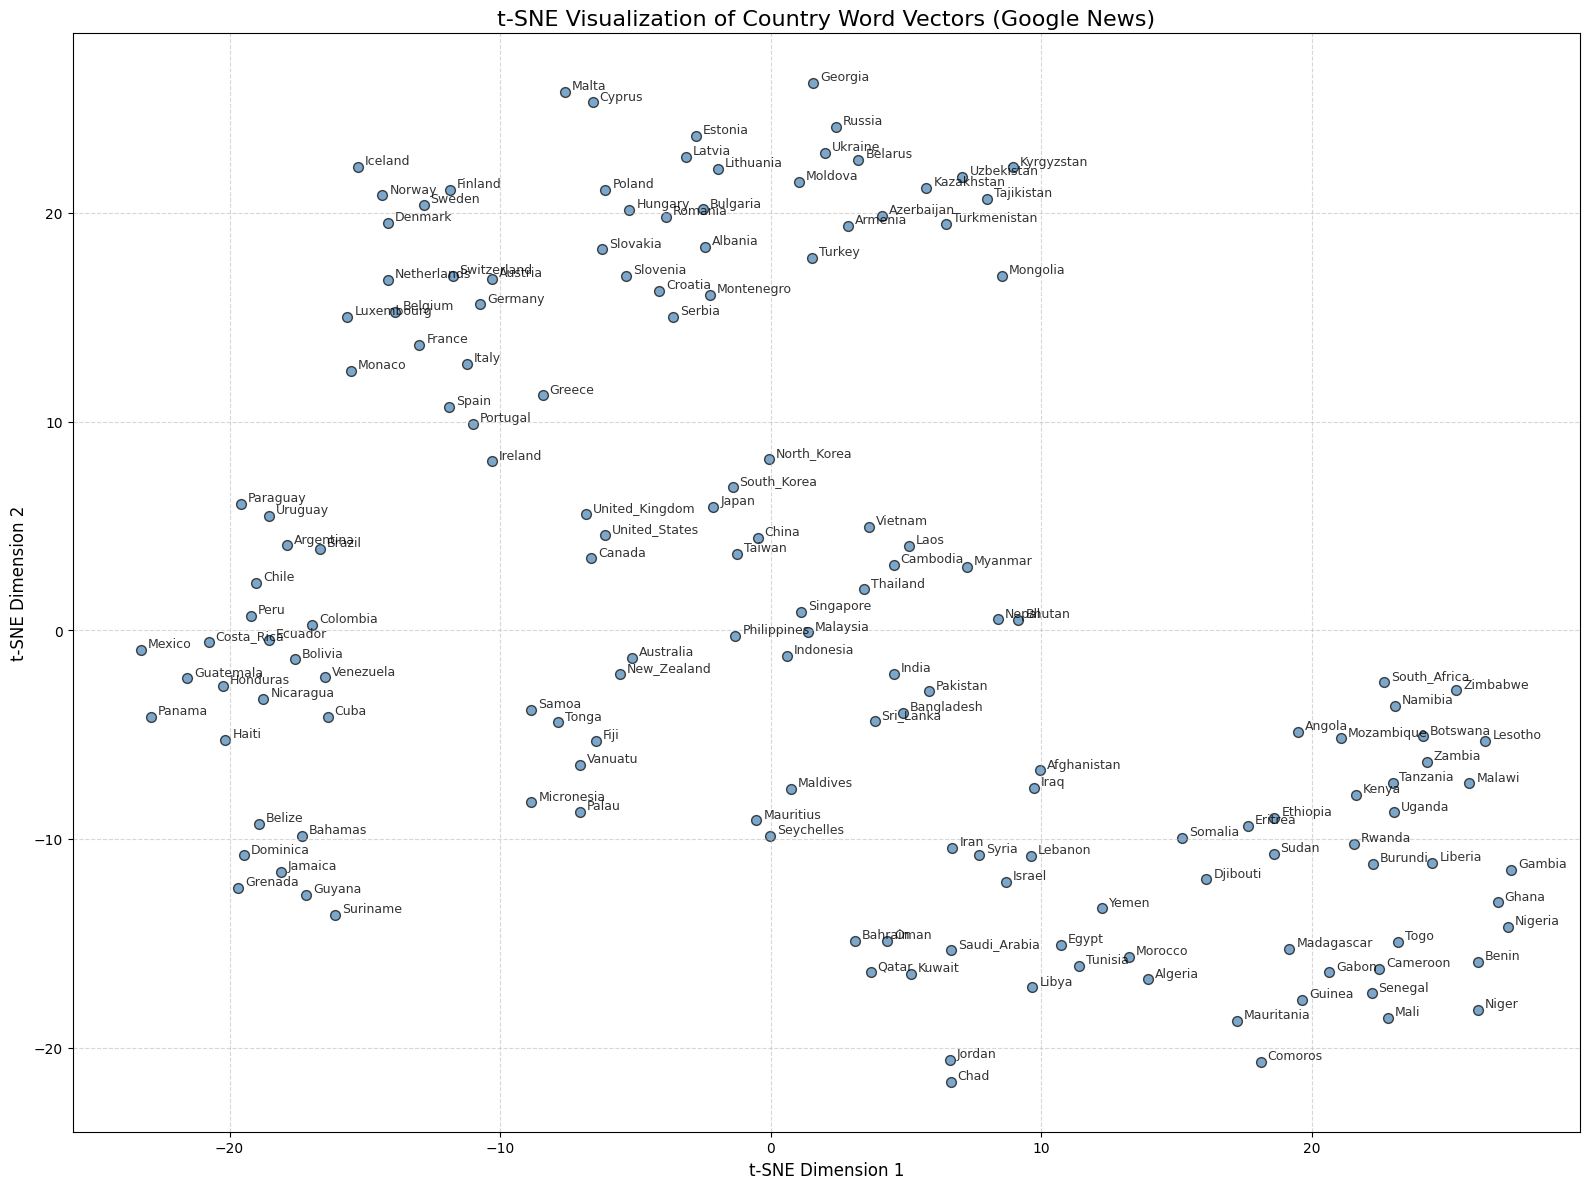

In [ ]:
# --- 3. 単語ベクトルの抽出 ---
valid_countries = []
country_vectors = []

for country in countries:
    if country in word_vectors:
        valid_countries.append(country)
        country_vectors.append(word_vectors[country])

# numpy配列に変換 (形状は サンプル数 x 300)
X = np.array(country_vectors)

# --- 4. t-SNEによる次元削減 ---
print("t-SNEによる次元削減を実行中... (数秒かかります)")
# 300次元を2次元に圧縮。
# perplexityは近傍のデータポイント数を考慮するパラメータ（データ数が少ない場合は小さめにするのがコツです）
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
X_tsne = tsne.fit_transform(X)

# --- 5. 散布図としての可視化 ---
print("グラフを描画します...")
plt.figure(figsize=(16, 12)) # プロットが重ならないように大きめのサイズを指定

# 散布図のプロット
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c='steelblue', edgecolors='k', alpha=0.7, s=50)

# 各プロットポイントに国名をテキストとして追加
for i, country in enumerate(valid_countries):
    # 点の少し右上にテキストを配置
    plt.annotate(
        country,
        (X_tsne[i, 0], X_tsne[i, 1]),
        fontsize=9,
        alpha=0.8,
        xytext=(5, 2),
        textcoords='offset points'
    )

# グラフの体裁を整える
plt.title("t-SNE Visualization of Country Word Vectors (Google News)", fontsize=16)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()